In [1]:

%load_ext autoreload
%autoreload 2

In [2]:
import sys
from pathlib import Path

project_root = Path().resolve().parents[1]
sys.path.append(str(Path().resolve().parents[1]))

In [3]:
import os
import re

import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx
from io import StringIO
import pandas as pd
import pickle
import igraph as ig
import torch

from grad.dataprep.util import create_pattern_dict, filter_dict
from grad.dataprep.util import *
from grad.dataprep.plotting_helpers import *
from grad.dataprep.generation import *
from util import *
from plotting_helpers import *

from simclr import * 
from augmentation import *

c:\Users\lucsc\anaconda3\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Using TensorFlow backend.


In [4]:
current_dir = os.path.dirname(os.getcwd())
CSV_PATH = os.path.join(current_dir, "data", "IBM", "Hi-Small_Trans.csv")
df_full = preprocess_df(CSV_PATH)
# df_full = preprocess_df()

In [39]:
with_laund_networks = extract_laundering_networks_igraph(
    df_full,
    max_depth=2,
    max_networks=2000,
    collapse_threshold=10
) 

In [40]:
# laundering_networks = extract_laundering_networks_igraph(df)

# Grab their sizes to match

non_laundering_networks = extract_non_laundering_networks_igraph(
    df_full,
    max_depth=2,
    max_networks=len(with_laund_networks),
    collapse_threshold=10)

In [49]:
networks = with_laund_networks + non_laundering_networks # laundering + non-laundering

for net in networks:
    net["graph"] = build_igraph_from_transactions(net["transactions"])

In [8]:
# for network in non_laundering_networks:
#     plot_graph_from_dict_igraph(network, show=True, save_path= f"non-laundering_network_{non_laundering_networks.index(network)}.png")

In [9]:
# full_graph = build_igraph_from_transactions(df_full)

# with_laund_networks[3]["graph"] = build_igraph_from_transactions(with_laund_networks[3]["transactions"])

In [10]:
# network_cropped = crop_network(with_laund_networks[3], crop_ratio=0.5, random_seed=42)

In [11]:
# network_deletions = delete_random_edges_bridge_safe(with_laund_networks[3], delete_frac
#                                         =0.15, random_seed=42)

In [12]:
# network_additions = add_nodes_to_network_incremental(with_laund_networks[3], full_graph, max_new_nodes=100)


In [13]:
# print(f"Number of nodes in deleted network: {len(network_deletions['nodes'])}")
# print(f"Number of transactions in deleted network: {len(network_deletions['transactions'])}")
# print(f"Number of transactions in original network: {len(with_laund_networks[3]['transactions'])}")

In [14]:
# plot_graph_from_dict_igraph(with_laund_networks[3], show=True, save_path="og_network.png")

In [15]:
# plot_graph_from_dict_igraph(network_additions, show=True, save_path="added_network.png")

In [16]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

encoder = GraphEncoder(in_dim=3, hidden_dim=64, out_dim=128).to(device)
projector = ProjectionHead(in_dim=128, proj_dim=64).to(device)

optimizer = torch.optim.Adam(
    list(encoder.parameters()) + list(projector.parameters()),
    lr=1e-3
)

In [17]:
print(device)

cuda


In [18]:
networks = with_laund_networks + non_laundering_networks # laundering + non-laundering

train_simclr_fast(
    networks=networks,     
    full_df=df_full,
    encoder=encoder,
    projector=projector,
    optimizer=optimizer,
    device=device,
    batch_size=32,
    epochs=1
)

Epoch 1/1
Epoch 1: avg loss = 3.3811 | time = 65.45s
New best model at epoch 1 with loss 3.3811
Best model saved at model_checkpoints\best_model.pt with loss 3.3811
Total training time: 65.45s


In [19]:
import torch
import numpy as np
import umap
import matplotlib.pyplot as plt

from torch_geometric.data import Batch

def plot_simclr_latent_space_laundering_vs_clean(
    networks,
    df_full
):
    """
    Plot the SimCLR encoder latent space, colored by presence of laundering nodes.
    """ 

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    checkpoint = torch.load("model_checkpoints/best_model.pt", map_location=device)

    encoder = GraphEncoder(in_dim=3, hidden_dim=64, out_dim=128).to(device)
    encoder.load_state_dict(checkpoint["encoder_state_dict"])
    encoder.eval()

    full_graph = prepare_networks(networks, df_full)

    graphs = []
    labels = []   # 1 = laundering present, 0 = none

    for net in networks:
        v = augment_network_view_fast(net, full_graph)
        graphs.append(network_to_pyg_data_fast(v))

        has_laundering = len(net["laundering_nodes"]) > 0
        labels.append(int(has_laundering))

    labels = np.array(labels)

    data = Batch.from_data_list(graphs).to(device)

    with torch.no_grad():
        h = encoder(data)

    H = h.cpu().numpy()

    # Normalize (important for contrastive models)
    H = H / np.linalg.norm(H, axis=1, keepdims=True)

    reducer = umap.UMAP(
        n_neighbors=15,
        min_dist=0.1,
        metric="cosine",
        random_state=42
    )

    H_2d = reducer.fit_transform(H)

    plt.figure(figsize=(8, 8))

    scatter = plt.scatter(
        H_2d[:, 0],
        H_2d[:, 1],
        c=labels,
        cmap="coolwarm",   # blue = non-laundering, red = laundering
        s=30,
        alpha=0.85
    )

    plt.title("SimCLR Encoder Latent Space\nRed = Laundering Networks | Blue = Clean Networks")
    plt.xticks([])
    plt.yticks([])

    cbar = plt.colorbar(scatter, ticks=[0, 1])
    cbar.ax.set_yticklabels(["No laundering nodes", "Has laundering nodes"])

    plt.tight_layout()
    plt.show()

    plt.savefig("simclr_latent_space_laundering_vs_clean.png", dpi=300)


c:\Users\lucsc\anaconda3\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


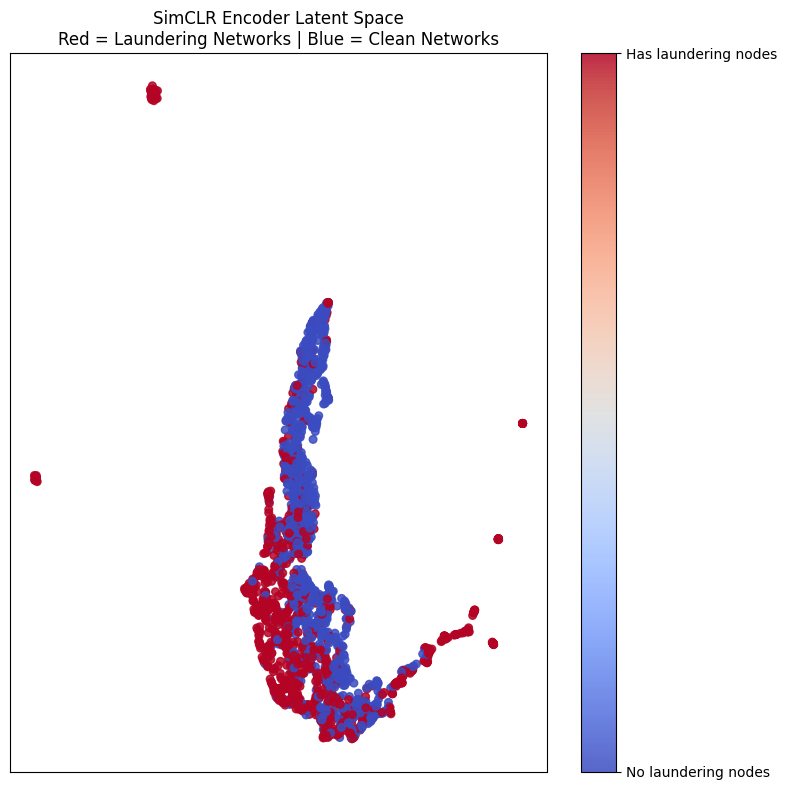

<Figure size 640x480 with 0 Axes>

In [20]:
plot_simclr_latent_space_laundering_vs_clean(networks, df_full) 

In [21]:
networks[5]

{'start_node': 1058,
 'nodes': {1058, 6356},
 'laundering_nodes': {1058, 6356},
 'collapsed_nodes': {6356},
 'node_depths': {1058: 0, 6356: 0},
 'transactions':              Timestamp From Bank    Account To Bank To Account  \
 1372  2022/09/01 00:09     03542  80034E560   03542  80034E560   
 8585  2022/09/01 00:20    011904  800EC5B80  011904  800EC5B80   
 
      Amount Received Receiving Currency Amount Paid Payment Currency  \
 1372          887.69          US Dollar      887.69        US Dollar   
 8585           23.57          US Dollar       23.57        US Dollar   
 
      Payment Format  Is Laundering         From_Node           To_Node  \
 1372   Reinvestment              0   03542_80034E560   03542_80034E560   
 8585   Reinvestment              0  011904_800EC5B80  011904_800EC5B80   
 
       To_Account_int  From_Account_int  
 1372            1058              1058  
 8585            6356              6356  ,
 'graph': <igraph.Graph at 0x22093655b50>}

In [22]:
def igraph_to_adj(graph: ig.Graph):
    """
    Convert igraph to dense adjacency tensor
    """
    A = np.array(graph.get_adjacency().data, dtype=np.float32)
    return torch.tensor(A)


def adj_to_igraph(adj: torch.Tensor):
    """
    Convert adjacency back to igraph
    """
    A = adj.cpu().numpy()

    # Threshold (important for diffusion output)
    A = (A > 0.5).astype(np.int32)

    g = ig.Graph.Adjacency(A.tolist(), mode="undirected")

    return g


In [23]:
class DiffusionScheduler:

    def __init__(self, T=500, beta_start=1e-4, beta_end=0.02, device="cuda"):

        self.T = T
        self.device = device

        self.beta = torch.linspace(
            beta_start, beta_end, T, device=device
        )

        self.alpha = 1.0 - self.beta
        self.alpha_bar = torch.cumprod(self.alpha, dim=0)

        self.sqrt_ab = torch.sqrt(self.alpha_bar)
        self.sqrt_1ab = torch.sqrt(1 - self.alpha_bar)


In [24]:
class GraphDenoiser(nn.Module):

    def __init__(self, hidden=64, T=500):
        super().__init__()

        self.time_emb = nn.Embedding(T, hidden)

        self.net = nn.Sequential(
            nn.Conv2d(2, hidden, 3, padding=1),
            nn.ReLU(),

            nn.Conv2d(hidden, hidden, 3, padding=1),
            nn.ReLU(),

            nn.Conv2d(hidden, 1, 3, padding=1)
        )


    def forward(self, x, t):
        """
        x: [B,1,N,N]
        t: [B]
        """

        t_emb = self.time_emb(t)
        t_emb = t_emb[:, :, None, None]

        t_ch = t_emb[:, :1]

        inp = torch.cat([x, t_ch.expand_as(x)], dim=1)

        return self.net(inp)


In [25]:
class IGraphDiffusionGenerator(nn.Module):

    def __init__(
        self,
        T=500,
        hidden=64,
        device="cuda"
    ):
        super().__init__()

        self.T = T
        self.device = device

        self.scheduler = DiffusionScheduler(T, device=device)

        self.denoiser = GraphDenoiser(hidden, T).to(device)


    # Forward noising
    def q_sample(self, x0, t, noise=None):

        if noise is None:
            noise = torch.randn_like(x0)

        sqrt_ab = self.scheduler.sqrt_ab[t][:, None, None, None]
        sqrt_1ab = self.scheduler.sqrt_1ab[t][:, None, None, None]

        xt = torch.clamp(xt, -3, 3)

        return xt, noise


    # Training loss
    def diffusion_loss(self, net):

        A = net["adj"].to(self.device)

        x0 = A.unsqueeze(0).unsqueeze(0)

        t = torch.randint(0, self.T, (1,), device=self.device)

        xt, noise = self.q_sample(x0, t)

        
        pred = self.denoiser(xt, t)

        return F.mse_loss(pred, noise)


    # Sampling (reverse process)
    @torch.no_grad()
    def sample(self, graph: ig.Graph):

        A = igraph_to_adj(graph)

        x = torch.randn(
            1, 1, A.shape[0], A.shape[1],
            device=self.device
        )

        for t in reversed(range(self.T)):

            t_batch = torch.tensor(
                [t], device=self.device
            )

            eps = self.denoiser(x, t_batch)

            alpha = self.scheduler.alpha[t]
            beta = self.scheduler.beta[t]
            alpha_bar = self.scheduler.alpha_bar[t]

            mean = (
                (1 / torch.sqrt(alpha)) *
                (x - beta / torch.sqrt(1 - alpha_bar) * eps)
            )

            if t > 0:
                z = torch.randn_like(x)
            else:
                z = 0

            x = mean + torch.sqrt(beta) * z


        adj = x[0, 0]

        adj = torch.sigmoid(adj)
        
        return adj_to_igraph(adj)


In [26]:
# diffusion = IGraphDiffusionGenerator().cuda()
# diffusion = torch.nn.DataParallel(diffusion)

# opt = torch.optim.Adam(
#     diffusion.parameters(),
#     lr=1e-4
# )

# for net in networks:
#     net["adj"] = igraph_to_adj(net["graph"])
    

# for epoch in range(5):

#     random.shuffle(networks)

#     total_loss = 0

#     accum_steps = 4   # how many graphs to accumulate over

#     opt.zero_grad()

#     for i in range(0, len(networks), 8):

#         batch = networks[i:i+8]

#         for j, net in enumerate(batch):

#             loss = diffusion.diffusion_loss(net) / accum_steps

#             loss.backward()

#             # update every accum_steps graphs
#             if (j + 1) % accum_steps == 0:

#                 opt.step()
#                 opt.zero_grad()

#         total_loss += loss.item()

#     print("Diff Epoch", epoch, total_loss)


In [27]:
from masked_diffusion import *

In [ ]:
import torch
from torch.utils.data import DataLoader
from torch.optim import Adam

from torch.cuda.amp import autocast, GradScaler

scaler = GradScaler()


from diffusion.dataset import CachedDataset
from diffusion.collate import collate_fn

from diffusion.model import DiffusionGNN
from diffusion.diff_util import create_diffusion, preprocess


# ----------------------------------
# Config
# ----------------------------------

BATCH_SIZE = 32          # you can increase now
LR = 2e-4
EPOCHS = 50
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

NODE_DIM = 3
HIDDEN = 128
TIMESTEPS = 1000


# ----------------------------------
# Dataset
# ----------------------------------

dataset = CachedDataset("cached_dataset.pt")


loader = DataLoader(

    dataset,

    batch_size=BATCH_SIZE,

    shuffle=True,

    collate_fn=collate_fn,

    num_workers=4,      # IMPORTANT
    pin_memory=True,    # IMPORTANT

    persistent_workers=True,
)


# ----------------------------------
# Model
# ----------------------------------

model = DiffusionGNN(
    node_dim=NODE_DIM,
    hidden_dim=HIDDEN,
    num_layers=4
).to(DEVICE)


# ----------------------------------
# Diffusion
# ----------------------------------

diffusion = create_diffusion(TIMESTEPS)


# ----------------------------------
# Optimizer
# ----------------------------------

optimizer = Adam(model.parameters(), lr=LR)


# ----------------------------------
# Training
# ----------------------------------

for epoch in range(EPOCHS):

    model.train()

    total_loss = 0


    for x, adj, node_mask in loader:

        x = x.to(DEVICE, non_blocking=True)
        adj = adj.to(DEVICE, non_blocking=True)
        node_mask = node_mask.to(DEVICE, non_blocking=True)


        # Mask adj
        adj = adj * node_mask[:, :, None] * node_mask[:, None, :]


        B = x.shape[0]


        t = torch.randint(
            0,
            diffusion.num_timesteps,
            (B,),
            device=DEVICE
        )


        with autocast():

            loss_dict = diffusion.training_losses(
                model,
                x_start=x,
                t=t,
                model_kwargs={
                    "adj": adj,
                    "node_mask": node_mask
                }
            )

            loss = loss_dict["loss"].mean()


        optimizer.zero_grad()

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()


        total_loss += loss.item()


    avg_loss = total_loss / len(loader)

    print(f"Epoch {epoch+1} | Loss: {avg_loss:.4f}")


    torch.save(model.state_dict(), "model.pt")